In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

In [2]:
# Load Our Filtered Data Set
file_path = Path("Data/clean/filtered_output.json")
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [3]:
# Exctract rthema per document
rthema_list = []
for content in data.values():
    themen = content.get("allgemeine-angaben", {}).get("rthema", [])
    rthema_list.extend(t.strip() for t in themen)

In [4]:
# Count occurrences of each rthema
rthema_counts = Counter(rthema_list)
rthema_df = pd.DataFrame(rthema_counts.items(), columns=["rthema", "count"]).sort_values(by="count", ascending=False)

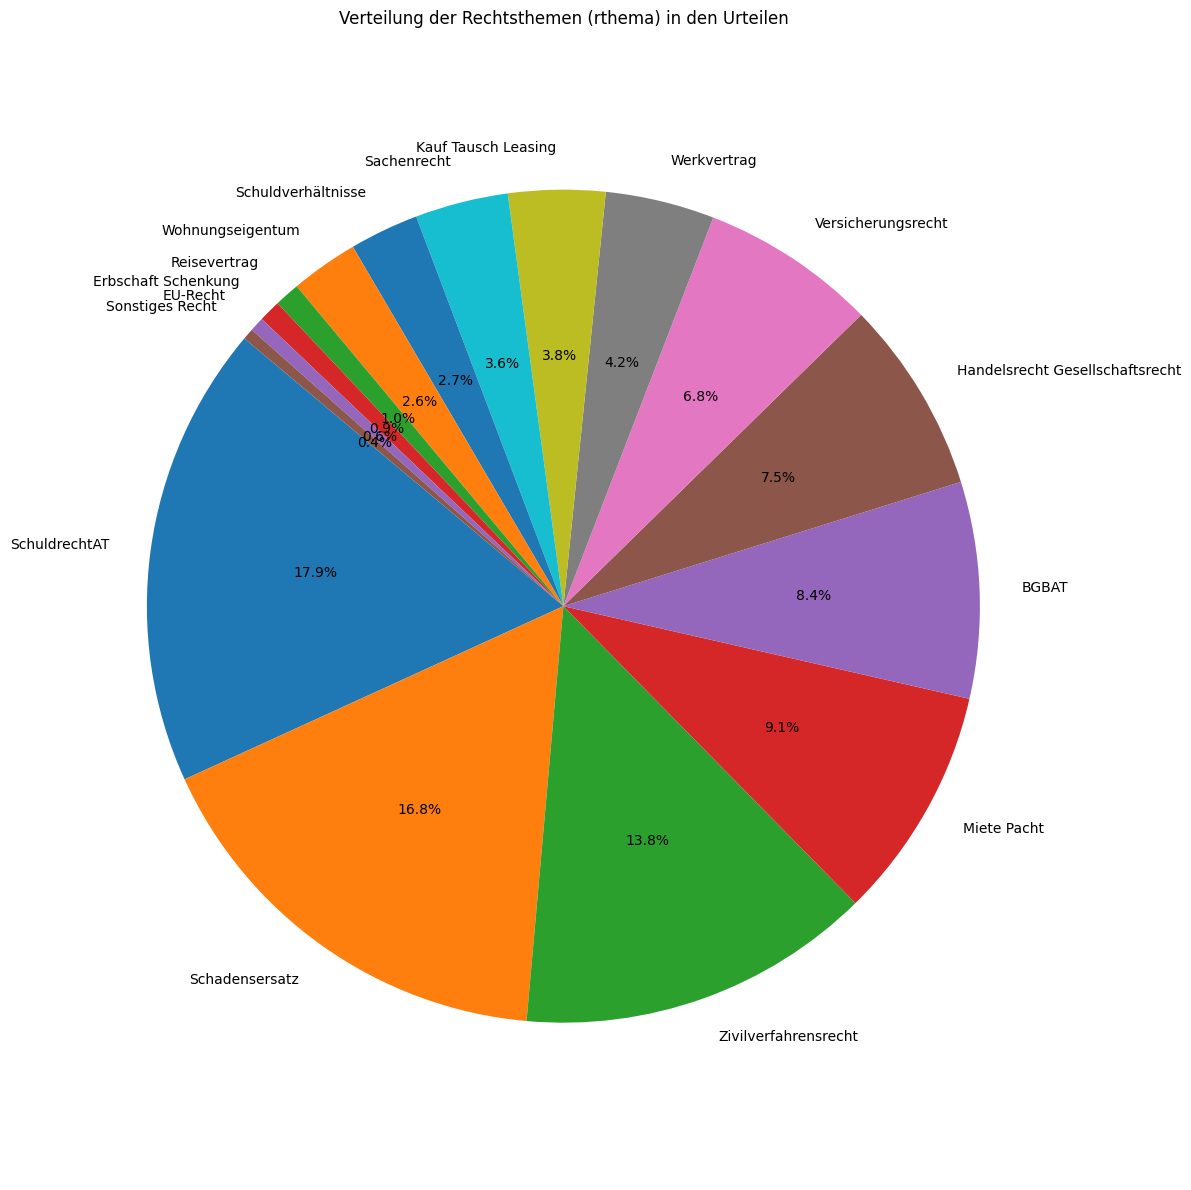

In [5]:
# Generate a pie chart for rthema distribution
plt.figure(figsize=(12, 12))
plt.pie(
    rthema_df["count"],
    labels=rthema_df["rthema"],
    autopct='%1.1f%%',
    startangle=140
)
plt.axis('equal')
plt.title("Verteilung der Rechtsthemen (rthema) in den Urteilen")
plt.tight_layout()
plt.show()